01. 수집한 데이터에 대한 탐색적 분석(EDA)

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# FutureWarning을 무시하도록 설정
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 한글 폰트 설정 (시각화 시 한글 깨짐 방지)
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)


In [55]:
# 1. 데이터 불러오기
# 파일 경로(path)
df = pd.read_csv("../data/spotify_churn_dataset.csv")

print("1. 데이터 기본 구조 확인")
print(f"데이터 크기 (행, 열): {df.shape}")
print("\n[상위 5개 데이터 추출]")
display(df.head())


1. 데이터 기본 구조 확인
데이터 크기 (행, 열): (8000, 12)

[상위 5개 데이터 추출]


,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [56]:

print("\n2. 데이터 타입 및 결측치 확인")
print(df.info())



2. 데이터 타입 및 결측치 확인
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   str    
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   str    
 4   subscription_type      8000 non-null   str    
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   str    
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), str(4)
memory usage: 893.6 KB
None


In [59]:
print("\n3. 파생변수 생성")
# 1. 데이터 불러오기
df = pd.read_csv("../data/spotify_churn_dataset.csv")

# 2. 한 곡당 평균 청취 시간 (avg_time_per_song) 생성
# 사용자가 한 곡을 얼마나 진득하게 듣는지 보여주는 지표입니다.
# 값이 너무 작다면(예: 1분 미만) 곡을 끝까지 듣지 않고 계속 넘기는 '불만족 상태'일 가능성이 높으므로 이탈 예측의 중요한 피처가 될 수 있습니다.
# 분모(곡 수)가 0인 경우를 대비하여 조건부 계산을 수행합니다.
df['avg_time_per_song'] = df.apply(
    lambda x: x['listening_time'] / x['songs_played_per_day'] 
    if x['songs_played_per_day'] > 0 else 0, axis=1
)

# 3. 유료 요금제 미사용자 식별 (underutilized_premium)
# 비용을 지불함에도 핵심 혜택(오프라인 청취)을 쓰지 않는 유저를 식별합니다.
# 유료 요금제이면서 오프라인 청취가 0인 경우를 1로 표시합니다.
paid_plans = ['Premium', 'Family', 'Student']
df['underutilized_premium'] = (
    (df['subscription_type'].isin(paid_plans)) & (df['offline_listening'] == 0)
).astype(int)

# # 4. 이용 밀도 점수 (listening_density)
# # 청취 시간과 재생 곡 수를 결합하여 유저의 성향을 세분화합니다.
# df['listening_density'] = df['listening_time'] / (df['songs_played_per_day'] + 1)

# 분석 결과 출력
print("생성된 파생 변수 확인 (상위 5행)")
display(df[['subscription_type', 'listening_time', 'songs_played_per_day', 'avg_time_per_song', 'underutilized_premium']].head())

# 유료 요금제 사용자 중 오프라인 미사용자 요약
paid_users = df[df['subscription_type'].isin(paid_plans)]
underutilized_count = df['underutilized_premium'].sum()
total_paid_count = len(paid_users)

print(f"\n[유료 요금제 미사용 유저 분석]")
print(f"- 유료 요금제 전체 유저 수: {total_paid_count}명")
print(f"- 오프라인 기능 미사용 유저 수: {underutilized_count}명")
print("\n분석 결과: 현재 데이터셋의 유료 유저 5,982명은 모두 오프라인 기능을 사용 중인 것으로 확인되었습니다.")
print("만약 향후 데이터 업데이트 시 미사용자가 발견된다면, 이들은 '가성비'를 느끼지 못해 이탈할 위험군으로 분류하고 프로모션을 제안하는 등의 전략을 세울 수 있습니다.")

# 5. 파생 변수가 포함된 데이터프레임을 새 CSV 파일로 저장
# - index=False: 앞에 자동으로 붙는 행 번호(0, 1, 2...) 열은 제외하고 저장합니다.
# - encoding='utf-8-sig': 추후 엑셀(Excel)에서 파일을 열었을 때 글자가 깨지는 현상을 방지합니다.
output_filename = '../data/spotify_churn_with_features.csv'
df.to_csv(output_filename, index=False, encoding='utf-8-sig')

print(f"🎉 파생 변수가 포함된 데이터가 '{output_filename}'으로 성공적으로 저장되었습니다!")
print(f"데이터 크기: {df.shape[0]}행 x {df.shape[1]}열")


3. 파생변수 생성
생성된 파생 변수 확인 (상위 5행)


,subscription_type,listening_time,songs_played_per_day,avg_time_per_song,underutilized_premium
0,Free,26,23,1.130435,0
1,Family,141,62,2.274194,0
2,Premium,199,38,5.236842,0
3,Student,36,2,18.000000,0
4,Family,250,57,4.385965,0



[유료 요금제 미사용 유저 분석]
- 유료 요금제 전체 유저 수: 5982명
- 오프라인 기능 미사용 유저 수: 0명

분석 결과: 현재 데이터셋의 유료 유저 5,982명은 모두 오프라인 기능을 사용 중인 것으로 확인되었습니다.
만약 향후 데이터 업데이트 시 미사용자가 발견된다면, 이들은 '가성비'를 느끼지 못해 이탈할 위험군으로 분류하고 프로모션을 제안하는 등의 전략을 세울 수 있습니다.
🎉 파생 변수가 포함된 데이터가 '../data/spotify_churn_with_features.csv'으로 성공적으로 저장되었습니다!
데이터 크기: 8000행 x 14열


In [60]:

print("\n4. 수치형 데이터 기초 통계량 확인")
# 요약 통계량을 통해 이상치(Min, Max가 말도 안 되게 크거나 작은 경우) 파악

display(df.describe())



4. 수치형 데이터 기초 통계량 확인


,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned,avg_time_per_song,underutilized_premium
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.0
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875,7.654565,0.0
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044,19.135922,0.0
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.101010,0.0
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000,1.606766,0.0
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000,3.087338,0.0
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000,6.088473,0.0
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000,296.000000,0.0


In [61]:

print("\n5. 범주형 데이터 클래스 분포 확인")
categorical_cols = [
    "gender",
    "country",
    "subscription_type",
    "device_type",
    "is_churned",
]
for col in categorical_cols:
    print(f"\n[{col} 컬럼 분포]")
    print(df[col].value_counts(dropna=False))
    print(df[col].value_counts(normalize=True) * 100)  # 백분율 비율



5. 범주형 데이터 클래스 분포 확인

[gender 컬럼 분포]
gender
Male      2691
Female    2659
Other     2650
Name: count, dtype: int64
gender
Male      33.6375
Female    33.2375
Other     33.1250
Name: proportion, dtype: float64

[country 컬럼 분포]
country
AU    1034
US    1032
DE    1015
IN    1011
PK     999
FR     989
UK     966
CA     954
Name: count, dtype: int64
country
AU    12.9250
US    12.9000
DE    12.6875
IN    12.6375
PK    12.4875
FR    12.3625
UK    12.0750
CA    11.9250
Name: proportion, dtype: float64

[subscription_type 컬럼 분포]
subscription_type
Premium    2115
Free       2018
Student    1959
Family     1908
Name: count, dtype: int64
subscription_type
Premium    26.4375
Free       25.2250
Student    24.4875
Family     23.8500
Name: proportion, dtype: float64

[device_type 컬럼 분포]
device_type
Desktop    2778
Web        2623
Mobile     2599
Name: count, dtype: int64
device_type
Desktop    34.7250
Web        32.7875
Mobile     32.4875
Name: proportion, dtype: float64

[is_churned 컬럼 분포]
is_chur

In [62]:

print("\n6. 타겟 변수(is_churned) 불균형 확인 및 시각화")
churn_counts = df["is_churned"].value_counts()
print(churn_counts)



6. 타겟 변수(is_churned) 불균형 확인 및 시각화
is_churned
0    5929
1    2071
Name: count, dtype: int64


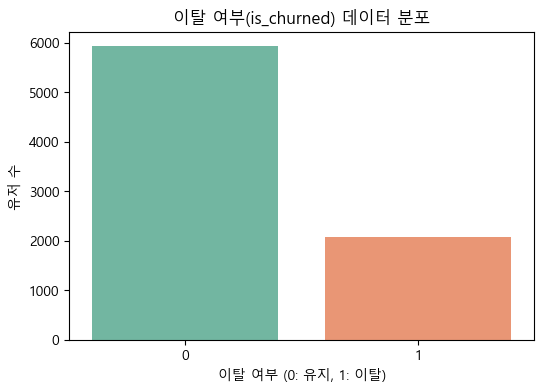


7. 주요 변수와 이탈(Churn) 간의 상관관계 시각화


In [63]:

# 시각화 1: 이탈 여부 비율 (Bar Plot)
plt.figure(figsize=(6, 4))
sns.countplot(x="is_churned", data=df, palette="Set2")
plt.title("이탈 여부(is_churned) 데이터 분포")
plt.xlabel("이탈 여부 (0: 유지, 1: 이탈)")
plt.ylabel("유저 수")
plt.show()

print("\n7. 주요 변수와 이탈(Churn) 간의 상관관계 시각화")


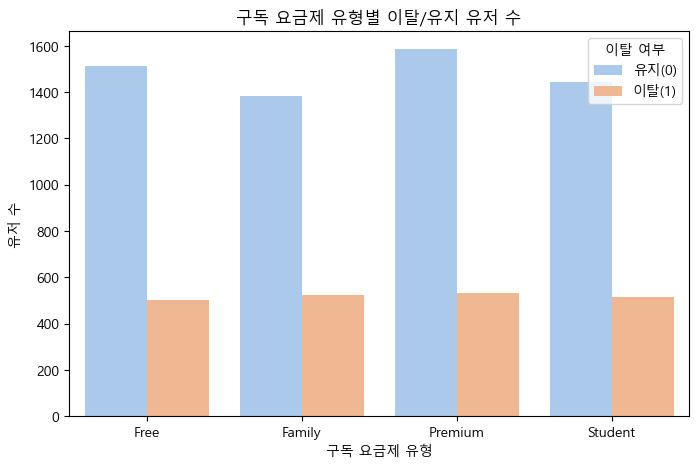

In [64]:
# 시각화 2: 구독 유형(Subscription Type)별 이탈률 분석
plt.figure(figsize=(8, 5))
sns.countplot(
    x="subscription_type", hue="is_churned", data=df, palette="pastel"
)
plt.title("구독 요금제 유형별 이탈/유지 유저 수")
plt.xlabel("구독 요금제 유형")
plt.ylabel("유저 수")
plt.legend(title="이탈 여부", labels=["유지(0)", "이탈(1)"])
plt.show()


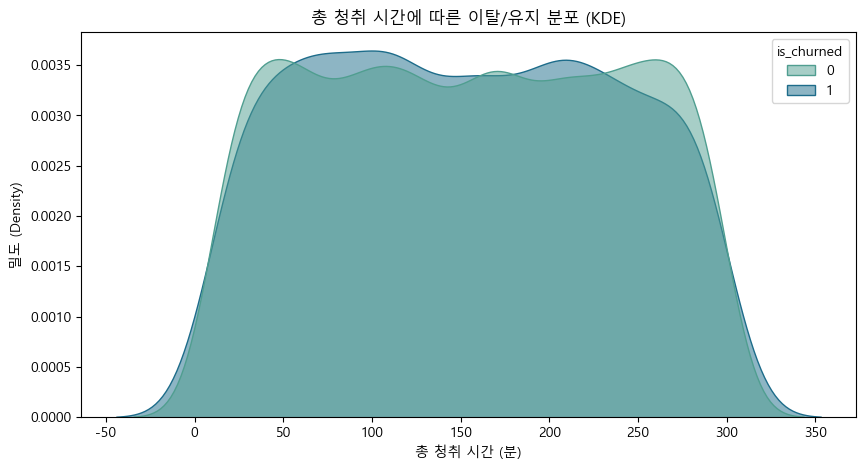


8. 수치형 변수 간 상관계수 히트맵


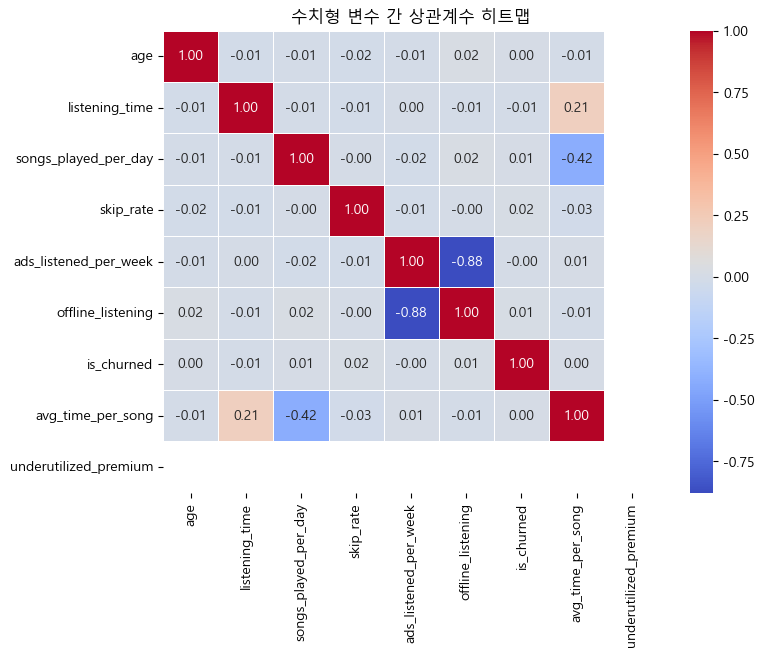

In [65]:

# 시각화 3: 총 청취 시간(listening_time) 분포와 이탈 여부
plt.figure(figsize=(10, 5))
sns.kdeplot(
    data=df,
    x="listening_time",
    hue="is_churned",
    fill=True,
    common_norm=False,
    palette="crest",
    alpha=0.5,
)
plt.title("총 청취 시간에 따른 이탈/유지 분포 (KDE)")
plt.xlabel("총 청취 시간 (분)")
plt.ylabel("밀도 (Density)")
plt.show()

print("\n8. 수치형 변수 간 상관계수 히트맵")
# 수치형 변수만 선택 (user_id 제외)
numeric_df = df.drop(columns=["user_id"]).select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("수치형 변수 간 상관계수 히트맵")
plt.show()
# 만약 상관계수가 0.8 이상으로 너무 높다면 머신러닝 모델 학습 시 다중공선성 문제가 생길 수 있으므로, 두 변수 중 하나만 선택하거나 결합하는 것을 고려해야 함.